In [13]:
import torch
import torchvision
import matplotlib.pyplot as plt
from tqdm import tqdm

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=0.1736, std=0.3317),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomVerticalFlip(p=0.5),
    torchvision.transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
])

target_transform = lambda y: 0 if y < 10 else 1  # 0 = digit, 1 = letter

test_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=0.1736, std=0.3317),
])

In [16]:
train = torchvision.datasets.EMNIST(root='./data',
                                    split='byclass',
                                    download=True,
                                    train=True,
                                    transform=train_transforms,
                                    target_transform=target_transform)
test = torchvision.datasets.EMNIST(root='./data',
                                   split='byclass',
                                   download=True,
                                   train=False,
                                   transform=test_transforms,
                                   target_transform=target_transform)

In [20]:
model = torch.nn.Sequential(
    torch.nn.Conv2d(1, 64, kernel_size=5,
                    padding = 1,
                    stride=1),
    torch.nn.Dropout(0.25),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Conv2d(64, 128, kernel_size=3,
                    padding = 1,
                    stride=1),
    torch.nn.Dropout(0.25),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Dropout(0.25),

    torch.nn.Flatten(),
    torch.nn.Linear(128 * 6 * 6, 256),

    torch.nn.Dropout(0.25),
    
    torch.nn.ReLU(),
    torch.nn.Linear(256, 1),
).to(device)

In [21]:
train_loader = torch.utils.data.DataLoader(train, batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=1024, shuffle=False, num_workers=4, pin_memory=True)

loss = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

In [22]:
EPOCHS = 5

train_losses = []
test_losses = []

smallest_test_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    loss_epoch = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        preds = model(images).squeeze(1)
        loss_value = loss(preds, labels.float())
        loss_epoch += loss_value.item()
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
    train_losses.append(loss_epoch / len(train_loader))
    print(f"Training Loss: {loss_epoch / len(train_loader)}")

    test_loss_epoch = 0.0
    for test_images, test_labels in test_loader:

        test_images, test_labels = test_images.to(device), test_labels.to(device)
        test_preds = model(test_images).squeeze(1)
        test_loss_value = loss(test_preds, test_labels.float())
        test_loss_epoch += test_loss_value.item()
    test_losses.append(test_loss_epoch / len(test_loader))

    if test_loss_epoch / len(test_loader) < smallest_test_loss:
        smallest_test_loss = test_loss_epoch / len(test_loader)
        torch.save(model.state_dict(), 'best_model.pth')
    torch.save(model.state_dict(), 'last_model.pth')

    print(f"Test Loss: {test_loss_epoch / len(test_loader)}")


Epoch 1/5


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [02:14<00:00,  5.07it/s]

Training Loss: 0.5561793758110567


Test Loss: 0.44867933842173796
Epoch 2/5


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [02:14<00:00,  5.07it/s]

...

Training Loss: 0.41192395867140763


Test Loss: 0.3640812319098857
Epoch 5/5


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [02:12<00:00,  5.16it/s]

Training Loss: 0.39895695264388387


Test Loss: 0.34874228688708525


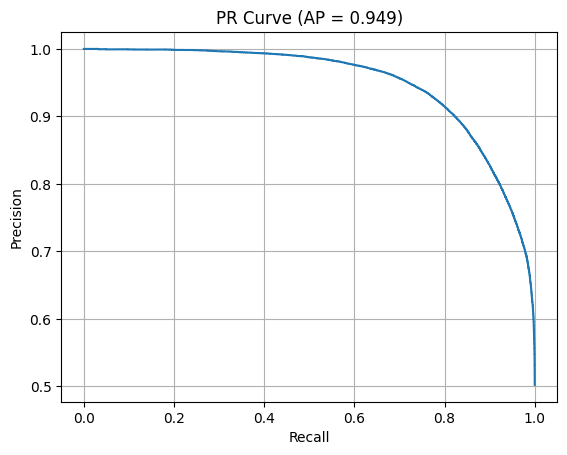

: 

In [ ]:
## test accuracy

import numpy as np

model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_probs = []
all_labels = []

for test_images, test_labels in test_loader:
    test_images, test_labels = test_images.to(device), test_labels.to(device)
    test_preds = model(test_images).squeeze(1)
    all_probs.extend(torch.sigmoid(test_preds).detach().cpu().numpy())
    all_labels.extend(test_labels.detach().cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)


from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)  # area under PR curve

import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AP = {ap:.3f})")
plt.grid(True)
plt.show()